Caso você encontre alguma dificuldade em executar no seu computador, clique aqui para abrir no colab.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ftl-brazil-2026/gis-python-basics/blob/main/python_gis_0.ipynb)

# Representando o Espaço com formas geométricas

- Como representar a casa onde vocês moram? 
- Como representar a rua da sua casa? 
- O bairro? A cidade? O estado? O país? 



## Simple Features

O Simple Features é um conjunto de normas que especifica um modelo comum de armazenamento e acesso a elementos geográficos compostos principalmente por geometrias bidimensionais (ponto, linha, polígono, multiponto, multilinha etc.), utilizados por bancos de dados geográficos e sistemas de informação geográfica. Ele é formalizado tanto pelo Open Geospatial Consortium (OGC) quanto pela Organização Internacional de Normalização (ISO).

![Screenshot 2026-08-13 at 11.05.09.png](<attachment:Screenshot 2026-08-13 at 11.05.09.png>)
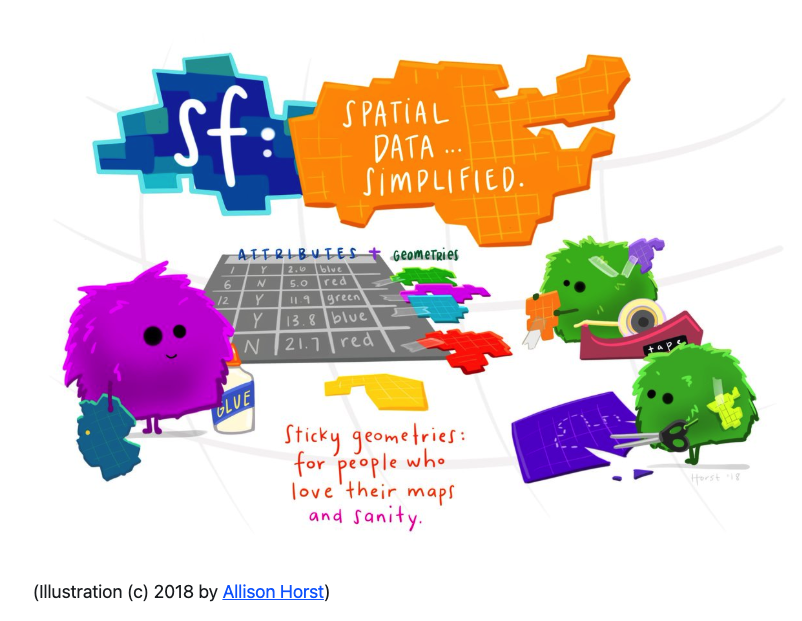

## O que é o OGC?

Link OGC website: https://www.ogc.org/

O **Open Geospatial Consortium (OGC)** é uma organização internacional fundada em 1994 que define padrões abertos para dados e serviços geoespaciais. Empresas, governos e universidades participam para garantir que sistemas diferentes consigam se comunicar.

### Principais padrões OGC:

| Padrão | Nome completo | Para que serve |
|---|---|---|
| **Simple Features** | Simple Feature Access | Modelo de geometrias e operações espaciais (Point, Line, Polygon…) |
| **WMS** | Web Map Service | Servir imagens de mapas na web |
| **WFS** | Web Feature Service | Servir dados vetoriais (geometrias + atributos) na web |
| **WCS** | Web Coverage Service | Servir dados raster (coberturas) na web |
| **GML** | Geography Markup Language | XML para representar dados geoespaciais |
| **KML** | Keyhole Markup Language | Formato do Google Earth |
| **GeoPackage** | GeoPackage | Container SQLite para dados geoespaciais |

Nesta aula, focaremos no **Simple Features**, que é a base de tudo.

# Well-Known-Features

O padrão **Simple Feature Access** (ISO 19125) define dois aspectos fundamentais:

### O modelo de geometrias

Toda geometria geoespacial é representada por uma hierarquia de classes:

```
Geometry
├── Point                    (ponto)
├── LineString               (linha)
│   └── LinearRing           (anel fechado)
├── Polygon                  (polígono)
├── MultiPoint               (múltiplos pontos)
├── MultiLineString          (múltiplas linhas)
├── MultiPolygon             (múltiplos polígonos)
└── GeometryCollection       (coleção genérica)
```

| Classe | Descrição | Exemplo do mundo real |
|---|---|---|
| **Point** | Um par (x, y) ou (x, y, z) | Localização de uma árvore, um poste, uma antena |
| **LineString** | Sequência de pontos conectados | Um trecho de rio, uma rua, uma linha de transmissão |
| **Polygon** | Uma área fechada com um anel externo e zero ou mais anéis internos (buracos) | Um lote, um município, um lago (com ilhas como buracos) |
| **MultiPoint** | Coleção de pontos | Várias árvores agrupadas |
| **MultiLineString** | Coleção de linhas | Um sistema de drenagem com vários rios |
| **MultiPolygon** | Coleção de polígonos | Um arquipélago (cada ilha é um polígono) |

###  As regras de validade

Para serem válidas, as geometrias precisam seguir regras topológicas:

- **Polygon**: O anel externo deve ser fechado (primeiro ponto = último ponto) e orientado no sentido anti-horário. Buracos (anéis internos) devem estar no sentido horário.
- **LineString** com apenas 2 pontos iguais é inválida.
- **MultiPolygon**: Os polígonos internos não podem se sobrepor.

Leia mais: https://en.wikipedia.org/wiki/Well-known_text_representation_of_geometry



![Screenshot 2026-08-13 at 10.58.33.png](<attachment:Screenshot 2026-08-13 at 10.58.33.png>)
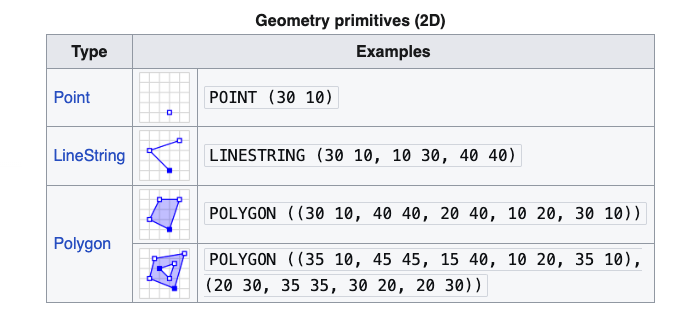

![Screenshot 2026-08-13 at 10.58.42.png](<attachment:Screenshot 2026-08-13 at 10.58.42.png>)
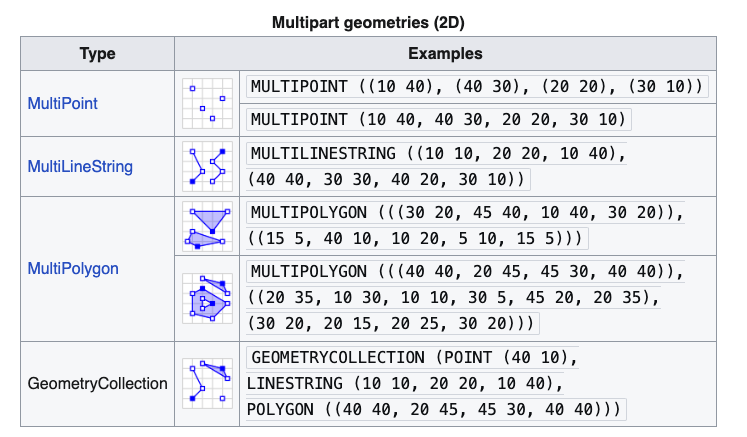

# Mao na massa

Vamos começar entendendo como gerar essas Well-Known-Features.

Nosso referencial aqui em python será: Shapely.

Embora outras linguages também forneçam funções de forma muito prática, por exemplo, em R, a biblioteca **sf** detém um trabalho fenomenal.

## Shapely — Introdução

**Shapely** é a biblioteca Python que implementa o modelo Simple Features. Ela é construída sobre a biblioteca C/C++ **GEOS** (Geometry Engine Open Source), que por sua vez é um porte da **JTS** (Java Topology Suite), a implementação de referência do padrão OGC.

> **Cadeia de dependência:** OGC (especificação) -> JTS (implementação Java) -> GEOS (porte C++) -> Shapely (binding Python) -> GeoPandas (DataFrame + Shapely)

Vamos criar nossas primeiras geometrias:

In [3]:
# import
# from shapely.geometry import Point, LineString, Polygon
from shapely.geometry import MultiPoint, MultiLineString, MultiPolygon, Point, LineString
from shapely.geometry import GeometryCollection
from shapely import wkt, wkb
import matplotlib.pyplot as plt

 

ps. Se você empacar nesse import, provavelmente é um erro relacionado ao GDAL ou libgeos. Certifique-se de ter GDAL instalado na sua máquina.

Check here: https://shapely.readthedocs.io/en/stable/installation.html

### Ponto

In [ ]:
Point?

In [5]:
ponto = Point(-47.66, -2.76)


In [12]:
print("Ponto:", ponto)
print("tipo:", ponto.geom_type)
print("coordenadas:", list(ponto.coords))
print("x =", ponto.x, "| y =", ponto.y)

Ponto: POINT (-47.66 -2.76)
tipo: Point
coordenadas: [(-47.66, -2.76)]
x = -47.66 | y = -2.76


### Linha

In [29]:
linha = LineString([(0, 0), (10, 5), (20, 0), (25, 10)])
print("Linha:", linha)
print("tipo:", linha.geom_type)
print("número de vértices:", len(list(linha.coords)))
print("coordenadas:", list(linha.coords))

Linha: LINESTRING (0 0, 10 5, 20 0, 25 10)
tipo: LineString
número de vértices: 4
coordenadas: [(0.0, 0.0), (10.0, 5.0), (20.0, 0.0), (25.0, 10.0)]


In [39]:
linha.coords

In [ ]:
linha = LineString([(0, 0), (10, 5), (20, 0), (25, 10),(0,0)])
linha

### Polygon

In [44]:
# from shapely import something

In [ ]:
poligono = Polygon([(0, 0), (10, 0), (10, 10), (0, 10), (0, 0)])
print("Polígono:", poligono)
print("tipo:", poligono.geom_type)
print("anel externo:", list(poligono.exterior.coords))



Polígono: POLYGON ((0 0, 10 0, 10 10, 0 10, 0 0))
  tipo: Polygon
  anel externo: [(0.0, 0.0), (10.0, 0.0), (10.0, 10.0), (0.0, 10.0), (0.0, 0.0)]


In [52]:
poligono.contains(ponto)

False

In [53]:
ponto2 = Point(1,1)

In [54]:
poligono.contains(ponto2)

True

In [56]:
poligono_com_buraco = Polygon(
    [(0, 0), (10, 0), (10, 10), (0, 10), (0, 0)],
    holes=[[(3, 3), (7, 3), (7, 7), (3, 7), (3, 3)]]
)
print("\nPolígono com buraco:", poligono_com_buraco)
print("número de buracos:", len(list(poligono_com_buraco.interiors)))


Polígono com buraco: POLYGON ((0 0, 10 0, 10 10, 0 10, 0 0), (3 3, 7 3, 7 7, 3 7, 3 3))
número de buracos: 1


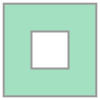

In [57]:
poligono_com_buraco

In [ ]:
Polygon?

### Geometrias Multi e coleções

In [58]:
multiponto = MultiPoint([(0, 0), (5, 5), (10, 0)])
print("MultiPoint:", multiponto)
print("  número de pontos:", len(multiponto.geoms))



MultiPoint: MULTIPOINT ((0 0), (5 5), (10 0))
  número de pontos: 3


In [59]:
multilinha = MultiLineString([
    [(0, 0), (5, 5), (10, 0)],
    [(0, 10), (5, 15), (10, 10)]
])
print("\nMultiLineString:", multilinha)
print("  número de linhas:", len(multilinha.geoms))




MultiLineString: MULTILINESTRING ((0 0, 5 5, 10 0), (0 10, 5 15, 10 10))
  número de linhas: 2


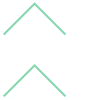

In [68]:
multilinha

In [60]:
multipoligono = MultiPolygon([
    Polygon([(0, 0), (5, 0), (5, 5), (0, 5)]),
    Polygon([(10, 10), (15, 10), (15, 15), (10, 15)])
])
print("\nMultiPolygon:", multipoligono)
print("  número de polígonos:", len(multipoligono.geoms))


MultiPolygon: MULTIPOLYGON (((0 0, 5 0, 5 5, 0 5, 0 0)), ((10 10, 15 10, 15 15, 10 15, 10 10)))
  número de polígonos: 2


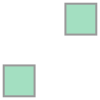

In [61]:
multipoligono

> **Dica:** Se você receber uma geometria e não souber o tipo, use `isinstance()` para verificar:
> ```python
> from shapely.geometry import Point, Polygon
> isinstance(ponto, Point)  # True
> isinstance(ponto, Polygon)  # False
> ```

In [71]:
isinstance(ponto, Point)

True

In [72]:
type(ponto)

shapely.geometry.point.Point

## Propriedades das geometrias

Toda geometria Shapely expõe propriedades calculadas automaticamente:

In [80]:
quadrado = Polygon([(0, 0), (10, 0), (10, 10), (0, 10)])

print("área:", quadrado.area)
print("perímetro:", quadrado.length)
print("centróide:", quadrado.centroid)
print("envelope (bbox):", quadrado.bounds)
print("tipo WKT:", quadrado.wkt)



área: 100.0
perímetro: 40.0
centróide: POINT (5 5)
envelope (bbox): (0.0, 0.0, 10.0, 10.0)
tipo WKT: POLYGON ((0 0, 10 0, 10 10, 0 10, 0 0))


In [ ]:
quadrado.p

shapely.geometry.polygon.Polygon

In [78]:
linha = LineString([(0, 0), (10, 10), (20, 0)])
print("  comprimento:", linha.length)
print("  área:", linha.area)
print("  centróide:", linha.centroid)
print("  envelope:", linha.bounds)


  comprimento: 28.284271247461902
  área: 0.0
  centróide: POINT (10 5)
  envelope: (0.0, 0.0, 20.0, 10.0)


In [77]:
ponto = Point(5, 5)

print("area:", ponto.area)
print("comprimento:", ponto.length)
print("centroide:", ponto.centroid)
print("envelope:", ponto.bounds)

area: 0.0
comprimento: 0.0
centroide: POINT (5 5)
envelope: (5.0, 5.0, 5.0, 5.0)


| Propriedade | Descrição | Ponto | Linha | Polígono |
|---|---|---|---|---|
| `.area` | Área da geometria | 0 | 0 | área preenchida |
| `.length` | Comprimento/perímetro | 0 | comprimento | perímetro do anel externo |
| `.centroid` | Centro geométrico | o próprio ponto | centro da linha | centro da área |
| `.bounds` | Retângulo envolvente mínimo (minx, miny, maxx, maxy) | ✓ | ✓ | ✓ |
| `.geom_type` | Tipo da geometria | `"Point"` | `"LineString"` | `"Polygon"` |
| `.wkt` | Representação Well-Known Text | ✓ | ✓ | ✓ |
| `.is_valid` | Se a geometria é topologicamente válida | ✓ | ✓ | ✓ |
| `.is_empty` | Se a geometria está vazia | ✓ | ✓ | ✓ |
| `.has_z` | Se tem coordenada Z (3D) | ✓ | ✓ | ✓ |

> **WKT (Well-Known Text)** é o formato de texto padronizado pela OGC para representar geometrias. `POINT(-46.63 -23.55)` é WKT. É como o "JSON" das geometrias, legível por humanos e sistemas.

In [84]:
linha.wkt

'LINESTRING (0 0, 10 10, 20 0)'

In [86]:
linha.wkb

b'\x01\x02\x00\x00\x00\x03\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00$@\x00\x00\x00\x00\x00\x00$@\x00\x00\x00\x00\x00\x004@\x00\x00\x00\x00\x00\x00\x00\x00'

In [94]:
hasattr(ponto.buffer(2),"geoms")

False

In [90]:
poligono.geom_type

'Polygon'

In [96]:
buf = ponto.buffer(2)
hasattr(buf,"geoms")

hasattr(ponto,"xy")

True

## Operações geométricas

Shapely oferece operações que transformam geometrias. São as mesmas operações que você faria num software GIS, mas programaticamente:

In [ ]:
import matplotlib.pyplot as plt
from shapely import affinity

ponto = Point(5, 5)
linha = LineString([(0, 0), (10, 0)])
poligono = Polygon([(2, 2), (8, 2), (8, 8), (2, 8)])

def plot_geoms(original, resultado, titulo_original="Original", titulo_resultado="Resultado"):
    """Função auxiliar para comparar geometrias antes e depois."""

    # cria a fig e os eixos de cada subplot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # faz um loop para duas listas, uma como os valores originais e a outra com os modificados 
    for ax, geom, titulo in [(ax1, original, titulo_original), (ax2, resultado, titulo_resultado)]:
        # quick-check para saber se contem geoms
        if hasattr(geom, "geoms"):
            for g in geom.geoms:
                xs, ys = g.exterior.xy if hasattr(g, "exterior") else g.xy if hasattr(g, "xy") else ([g.x], [g.y])
                ax.fill(xs, ys, alpha=0.4) if hasattr(g, "exterior") else ax.plot(xs, ys, "bo-")

        # senao contem geoms, entao verifica se contain exterior
        elif hasattr(geom, "exterior"):
            xs, ys = geom.exterior.xy
            ax.fill(xs, ys, alpha=0.4, color="blue")
            for interior in geom.interiors:
                ix, iy = interior.xy
                ax.fill(ix, iy, alpha=0.8, color="white")

        # senao contem os dois acima, verifica se contem o atributo 
        elif hasattr(geom, "xy"):
            xs, ys = geom.xy
            ax.plot(xs, ys, "bo-")
        else:
            ax.plot(geom.x, geom.y, "ro")
        ax.set_title(titulo)
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Buffer ao redor de um ponto:
  área do buffer: 12.546193962183755
  perímetro do buffer: 12.561324627819015


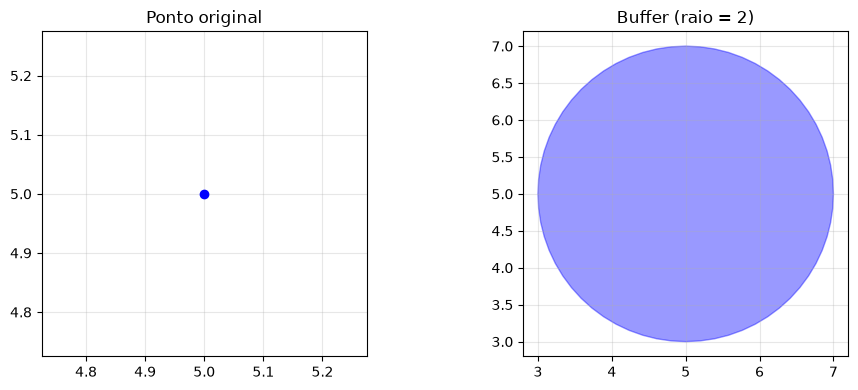

In [88]:
print("Buffer ao redor de um ponto:")
buf = ponto.buffer(2)
print("  área do buffer:", buf.area)
print("  perímetro do buffer:", buf.length)
plot_geoms(ponto, buf, "Ponto original", "Buffer (raio = 2)")

Envelope convexo (convex hull):


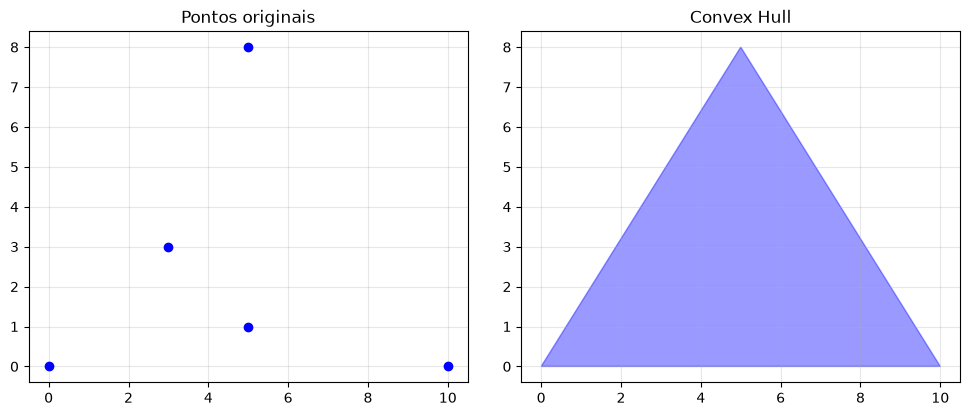

In [97]:
print("Envelope convexo (convex hull):")
pts = MultiPoint([(0, 0), (5, 1), (10, 0), (5, 8), (3, 3)])
hull = pts.convex_hull
plot_geoms(pts, hull, "Pontos originais", "Convex Hull")

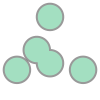

In [99]:
pts.buffer(2)

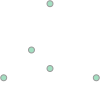

In [101]:
pts

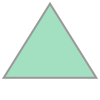

In [100]:
pts.convex_hull

In [ ]:
pts.convex_hull.

> Um convex hull (ou fecho convexo) é o menor polígono convexo que consegue envolver completamente um conjunto de pontos em um plano ou espaço

#### Simplificacao de geometria | **Simplify**

Simplificação de geometria:
vértices antes: 11 → depois: 2


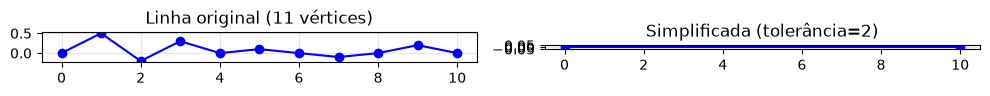

In [104]:
print("Simplificação de geometria:")
complexa = LineString([(0, 0), (1, 0.5), (2, -0.2), (3, 0.3), (4, 0), (5, 0.1), (6, 0), (7, -0.1), (8, 0), (9, 0.2), (10, 0)])
simplificada = complexa.simplify(2.0, preserve_topology=True)
print(f"vértices antes: {len(list(complexa.coords))} → depois: {len(list(simplificada.coords))}")
plot_geoms(complexa, simplificada, "Linha original (11 vértices)", "Simplificada (tolerância=2)")

In [106]:
complexa.simplify?

Signature: complexa.simplify(tolerance, preserve_topology=True)
Docstring:
Return a simplified geometry produced by the Douglas-Peucker algorithm.

Coordinates of the simplified geometry will be no more than the
tolerance distance from the original. Unless the topology preserving
option is used, the algorithm may produce self-intersecting or
otherwise invalid geometries.
File:      ~/Documents/UN/materials/gis-python/.venv/lib/python3.13/site-packages/shapely/geometry/base.py
Type:      method

> Qual a razão de simplificarmos alguma geometria? Não seria melhor preservar a estrutura original dela? 

| Operação | Método | Uso típico |
|---|---|---|
| **Buffer** | `.buffer(distancia)` | Criar área de influência ao redor de um ponto, rio ou estrada |
| **Envelope** | `.envelope` | Calcular o retângulo envolvente mínimo (bbox) |
| **Convex Hull** | `.convex_hull` | Encontrar o menor polígono convexo que contém um conjunto de pontos |
| **Simplify** | `.simplify(tolerancia)` | Reduzir o número de vértices mantendo a forma geral |
| **Affine** | `shapely.affinity.translate/rotate/scale` | Mover, rotacionar, escalar geometrias |

### Affine | Transformações 

In [ ]:
## opencode, inclua aqui alguma operacao aqui com Affine.

## pelo menos dois exemplos 

## Relações espaciais (predicados) | Spatial Relations - Topology

Predicados espaciais são funções que respondem perguntas do tipo **"A está dentro de B?"** ou **"A toca B?"**. Eles retornam `True` ou `False` e são a base de qualquer análise espacial.

O padrão OGC define 8 predicados. Vamos visualizar cada um:

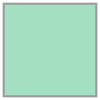

In [110]:
from shapely.geometry import box

A = box(2, 2, 6, 6)
A

In [111]:
A.bounds

(2.0, 2.0, 6.0, 6.0)

In [ ]:

dentro = box(3, 3, 5, 5)
fora = box(10, 10, 12, 12)
tocando = box(6, 3, 8, 5)
intersectando = box(4, 4, 8, 8)
cruzando = LineString([(0, 4), (8, 4)])
sobrepondo = box(4, 4, 8, 8)

print("dentro de A?              within:", A.contains(dentro), "→ dentro está contido em A")
print("fora de A?                disjoint:", A.disjoint(fora), "→ fora é disjunto de A")
print("tocando A?                touches:", A.touches(tocando), "→ compartilham fronteira")
print("intersecta A?             intersects:", A.intersects(intersectando), "→ qualquer interseção")
print("cruza A?                  crosses:", A.crosses(cruzando), "→ linha cruza polígono")
print("sobrepõe A?               overlaps:", A.overlaps(sobrepondo), "→ mesma dimensão, sobreposição parcial")

dentro de A?              within: True → dentro está contido em A
fora de A?                disjoint: True → fora é disjunto de A
tocando A?                touches: True → compartilham fronteira
intersecta A?             intersects: True → qualquer interseção
cruza A?                  crosses: True → linha cruza polígono
sobrepõe A?               overlaps: True → mesma dimensão, sobreposição parcial


In [118]:
type(A.exterior)

shapely.geometry.polygon.LinearRing

In [119]:
type(A)

shapely.geometry.polygon.Polygon

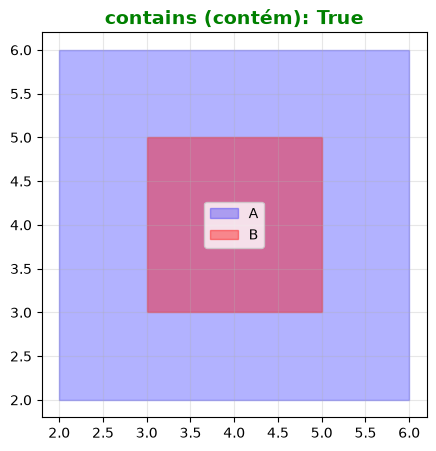

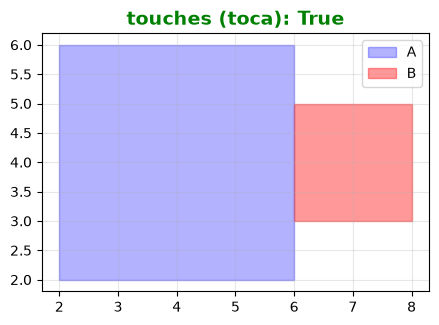

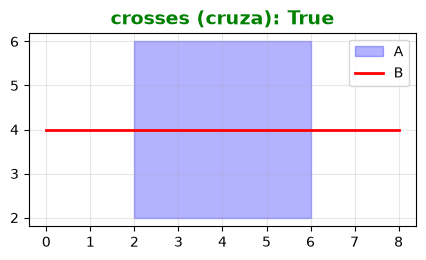

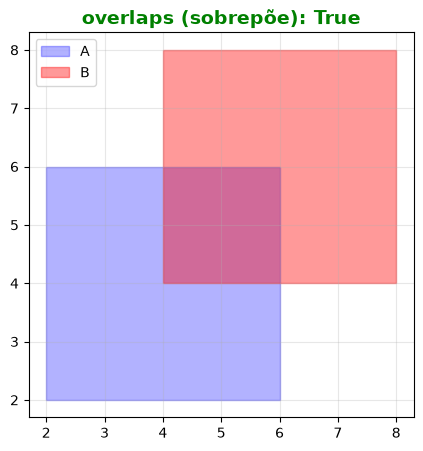

In [112]:
# funcao auxiliar para visualizar os predicados 
def visualizar_predicado(A, B, predicado_nome, resultado):
    fig, ax = plt.subplots(figsize=(5, 5))

    xs_a, ys_a = A.exterior.xy
    ax.fill(xs_a, ys_a, alpha=0.3, color="blue", label="A")

    if hasattr(B, "exterior"):
        xs_b, ys_b = B.exterior.xy
        ax.fill(xs_b, ys_b, alpha=0.4, color="red", label="B")
    elif hasattr(B, "xy"):
        xs_b, ys_b = B.xy
        ax.plot(xs_b, ys_b, "r-", linewidth=2, label="B")
    else:
        ax.plot(B.x, B.y, "ro", markersize=10, label="B")

    cor = "green" if resultado else "red"
    ax.set_title(f"{predicado_nome}: {resultado}", fontsize=14, color=cor, weight="bold")
    ax.set_aspect("equal")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

visualizar_predicado(A, dentro, "contains (contém)", A.contains(dentro))
visualizar_predicado(A, tocando, "touches (toca)", A.touches(tocando))
visualizar_predicado(A, cruzando, "crosses (cruza)", A.crosses(cruzando))
visualizar_predicado(A, sobrepondo, "overlaps (sobrepõe)", A.overlaps(sobrepondo))

### Tabela resumo dos 8 predicados OGC:

| Predicado | Método Shapely | Significado |
|---|---|---|
| **Equals** | `.equals(B)` | A e B são topologicamente iguais |
| **Disjoint** | `.disjoint(B)` | A e B não têm nenhum ponto em comum |
| **Intersects** | `.intersects(B)` | A e B têm pelo menos um ponto em comum (o mais genérico) |
| **Touches** | `.touches(B)` | A e B se tocam apenas na fronteira, sem sobrepor interiores |
| **Crosses** | `.crosses(B)` | A e B se cruzam (dimensões diferentes: linha × polígono) |
| **Within** | `.within(B)` | A está completamente dentro de B |
| **Contains** | `.contains(B)` | A contém completamente B (inverso de within) |
| **Overlaps** | `.overlaps(B)` | A e B se sobrepõem parcialmente (mesma dimensão) |

> **Visual cheat sheet:** Veja o [DE-9IM](https://en.wikipedia.org/wiki/DE-9IM) (Dimensionally Extended 9-Intersection Model) — é a matriz 3×3 que define formalmente cada predicado.

## Operações de conjunto (set operations)

Assim como podemos perguntar sobre relações espaciais, podemos **criar novas geometrias** combinando geometrias existentes:

In [ ]:
# auxiliar function

def plot_set_op(A, B, resultado, titulo):
    fig, ax = plt.subplots(figsize=(5, 5))
    xs_a, ys_a = A.exterior.xy
    xs_b, ys_b = B.exterior.xy
    ax.fill(xs_a, ys_a, alpha=0.3, color="blue", label="A")
    ax.fill(xs_b, ys_b, alpha=0.3, color="red", label="B")

    if hasattr(resultado, "geoms"):
        for g in resultado.geoms:
            xs, ys = g.exterior.xy
            ax.fill(xs, ys, alpha=0.6, color="green", edgecolor="black", linewidth=1.5)
    elif not resultado.is_empty:
        if hasattr(resultado, "exterior"):
            xs, ys = resultado.exterior.xy
            ax.fill(xs, ys, alpha=0.6, color="green", edgecolor="black", linewidth=1.5)
        elif hasattr(resultado, "xy"):
            xs, ys = resultado.xy
            ax.plot(xs, ys, "g-", linewidth=2)

    ax.set_title(titulo, fontsize=13)
    ax.set_aspect("equal")
    ax.legend()
    ax.grid(True, alpha=0.2)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 8)
    plt.show()



In [10]:
from shapely.geometry import box
A = box(1, 1, 5, 5)
B = box(3, 3, 8, 6)

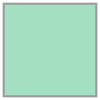

In [12]:
A

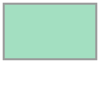

In [13]:
B

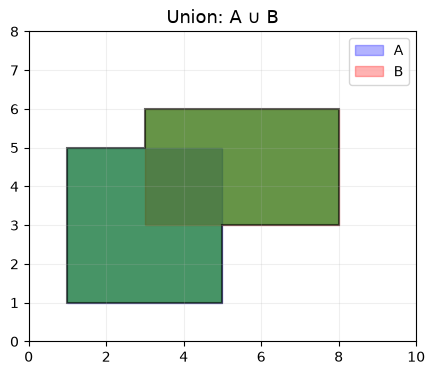

In [6]:
uniao = A.union(B)
intersec = A.intersection(B)
diferenca = A.difference(B)
diferenca_b_a = B.difference(A)
diferenca_simetrica = A.symmetric_difference(B)

plot_set_op(A, B, uniao, "Union: A ∪ B")

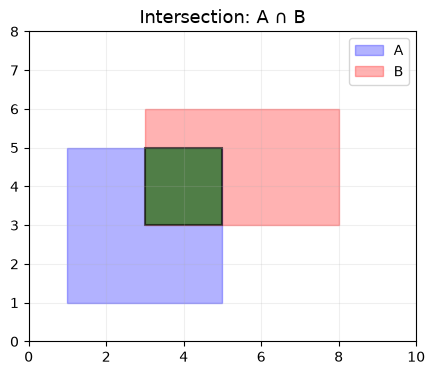

In [7]:

plot_set_op(A, B, intersec, "Intersection: A ∩ B")


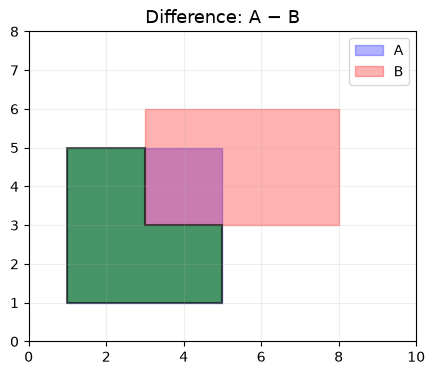

In [8]:
plot_set_op(A, B, diferenca, "Difference: A − B")


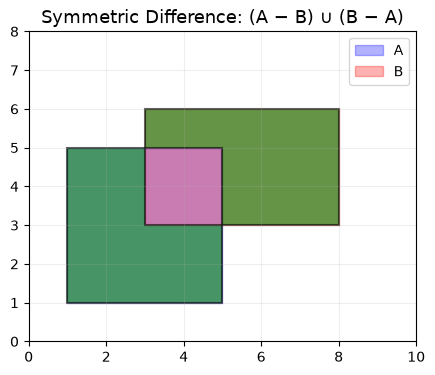

In [9]:
plot_set_op(A, B, diferenca_simetrica, "Symmetric Difference: (A − B) ∪ (B − A)")

| Operação | Método | Resultado |
|---|---|---|
| **Union** | `.union(B)` | Geometria com todos os pontos de A e B combinados |
| **Intersection** | `.intersection(B)` | Apenas a área comum a A e B |
| **Difference** | `.difference(B)` | Área de A que não está em B ("cortar" B de A) |
| **Symmetric Difference** | `.symmetric_difference(B)` | Área que está em A ou em B, mas não em ambos (XOR) |

Essas operações são o equivalente geoespacial das operações de conjunto da matemática ( ∪ ∩ − ⊕ ).

## 2.9 Formato WKT e WKB

Dois formatos fundamentais para intercâmbio de geometrias:

In [ ]:
from shapely import wkt, wkb

pol = Polygon([(0, 0), (10, 0), (10, 10), (0, 10)])

wkt_str = pol.wkt
print("WKT (texto legível):", wkt_str)

wkb_bytes = pol.wkb
print("WKB (binário):", wkb_bytes[:40], "...")

pol_de_wkt = wkt.loads(wkt_str)
pol_de_wkb = wkb.loads(wkb_bytes)

print("\nIda e volta WKT:", pol.equals(pol_de_wkt))
print("Ida e volta WKB:", pol.equals(pol_de_wkb))

> **WKT** é ótimo para depuração, logs e configuração. **WKB** é eficiente para armazenamento e transmissão (bancos de dados como PostGIS usam WKB internamente).

Recapitulando:

Agora sabemos como criar e manipular geometrias. Porém ainda não estamos organizando essas geometrias em algo estruturado, como um dataframe.

Isso nos leva a entender melhor como **Geopandas** facilita a nossa vida.

Recomendações e leituras: 

- R-spatial Workbook:  https://r-spatial.github.io/sf/